In [2]:
def imprimir_tablero(individuo, N: int = 8) -> None:
    if individuo is None:
        return
    
    linea = "+---" * N + "+"

    for i in range(N):
        print(linea)
        fila = ""
        for j in range(N):
            if individuo[j] == i:
                fila += "| Q "
            else:
                fila += "|   "
        fila += "|"
        print(fila)

    print(linea)

In [3]:
# Ejemplo de la impresión de un individuo
imprimir_tablero([6,1,3,2,5,7,4,0])

+---+---+---+---+---+---+---+---+
|   |   |   |   |   |   |   | Q |
+---+---+---+---+---+---+---+---+
|   | Q |   |   |   |   |   |   |
+---+---+---+---+---+---+---+---+
|   |   |   | Q |   |   |   |   |
+---+---+---+---+---+---+---+---+
|   |   | Q |   |   |   |   |   |
+---+---+---+---+---+---+---+---+
|   |   |   |   |   |   | Q |   |
+---+---+---+---+---+---+---+---+
|   |   |   |   | Q |   |   |   |
+---+---+---+---+---+---+---+---+
| Q |   |   |   |   |   |   |   |
+---+---+---+---+---+---+---+---+
|   |   |   |   |   | Q |   |   |
+---+---+---+---+---+---+---+---+


In [35]:
import numpy as np
import numpy.typing as npt
import random

def generar_poblacion() -> npt.NDArray[np.int8]:

    poblacion = []

    for _ in range(100):
        individuo = np.random.permutation(8)
        poblacion.append(individuo)

    return np.array(poblacion, dtype=np.int8)

In [5]:
poblacion = generar_poblacion()
poblacion 

array([[1, 7, 2, 4, 1, 2, 7, 3],
       [1, 3, 3, 2, 0, 3, 7, 1],
       [2, 6, 5, 1, 5, 3, 0, 0],
       [5, 1, 3, 3, 6, 3, 3, 7],
       [5, 0, 5, 0, 3, 0, 3, 7],
       [1, 0, 6, 6, 4, 0, 1, 4],
       [0, 4, 7, 4, 4, 0, 1, 0],
       [2, 0, 1, 5, 3, 4, 0, 5],
       [6, 7, 4, 2, 6, 6, 3, 2],
       [2, 7, 4, 0, 6, 7, 2, 7],
       [4, 7, 6, 2, 3, 7, 2, 2],
       [3, 5, 2, 7, 7, 0, 1, 7],
       [6, 1, 3, 6, 3, 4, 0, 2],
       [2, 6, 2, 4, 7, 6, 2, 0],
       [3, 1, 3, 5, 3, 0, 1, 0],
       [0, 7, 7, 1, 6, 3, 3, 6],
       [2, 6, 3, 1, 2, 7, 1, 7],
       [2, 4, 7, 1, 2, 1, 7, 3],
       [4, 7, 2, 2, 1, 3, 0, 2],
       [7, 5, 3, 0, 3, 3, 6, 0],
       [3, 1, 1, 0, 5, 7, 4, 5],
       [2, 6, 4, 6, 1, 2, 2, 2],
       [3, 1, 7, 3, 2, 2, 1, 1],
       [2, 0, 7, 4, 3, 0, 0, 7],
       [7, 4, 6, 0, 4, 3, 4, 6],
       [1, 0, 5, 3, 6, 5, 5, 2],
       [6, 3, 3, 2, 1, 1, 7, 4],
       [0, 5, 3, 1, 3, 6, 4, 2],
       [5, 4, 2, 5, 3, 4, 4, 0],
       [1, 3, 7, 5, 4, 0, 3, 7],
       [5,

In [6]:

def calcular_aptitud(poblacion: npt.NDArray[np.int8]) -> list[int]:
    """Calcula el número de conflictos (aptitud o fitness)."""
    fitnes: list[int] = []
    # TODO: Calcula el número de conflictos si un par de reinas están en la misma fila
    # o si están en la misma diagonal.
    # No pueden estar en la misma columna debido a que la representación no lo permite,
    # solo hay una reina por columna.
    for individuo in poblacion:
        conflictos: int = 0
        for i in range(8):
            for k in range(i+1, 8):
                if individuo[i] == individuo[k]:
                    conflictos += 1
                if abs(i - k) == abs(individuo[i] - individuo[k]):
                    conflictos += 1
        fitnes.append(conflictos)
    return fitnes

In [7]:
aptitud = calcular_aptitud(poblacion)

In [8]:
fitness_max = np.max(aptitud)
fitness_min = np.min(aptitud)
fitness_mean = np.mean(aptitud)
print(fitness_max)
print(fitness_min)
print(fitness_mean)

18
3
7.91


In [9]:
poblacion = list(zip(poblacion, aptitud))


In [10]:
poblacion

[(array([1, 7, 2, 4, 1, 2, 7, 3], dtype=int32), 8),
 (array([1, 3, 3, 2, 0, 3, 7, 1], dtype=int32), 10),
 (array([2, 6, 5, 1, 5, 3, 0, 0], dtype=int32), 6),
 (array([5, 1, 3, 3, 6, 3, 3, 7], dtype=int32), 10),
 (array([5, 0, 5, 0, 3, 0, 3, 7], dtype=int32), 9),
 (array([1, 0, 6, 6, 4, 0, 1, 4], dtype=int32), 7),
 (array([0, 4, 7, 4, 4, 0, 1, 0], dtype=int32), 12),
 (array([2, 0, 1, 5, 3, 4, 0, 5], dtype=int32), 9),
 (array([6, 7, 4, 2, 6, 6, 3, 2], dtype=int32), 8),
 (array([2, 7, 4, 0, 6, 7, 2, 7], dtype=int32), 11),
 (array([4, 7, 6, 2, 3, 7, 2, 2], dtype=int32), 9),
 (array([3, 5, 2, 7, 7, 0, 1, 7], dtype=int32), 7),
 (array([6, 1, 3, 6, 3, 4, 0, 2], dtype=int32), 7),
 (array([2, 6, 2, 4, 7, 6, 2, 0], dtype=int32), 9),
 (array([3, 1, 3, 5, 3, 0, 1, 0], dtype=int32), 10),
 (array([0, 7, 7, 1, 6, 3, 3, 6], dtype=int32), 6),
 (array([2, 6, 3, 1, 2, 7, 1, 7], dtype=int32), 6),
 (array([2, 4, 7, 1, 2, 1, 7, 3], dtype=int32), 6),
 (array([4, 7, 2, 2, 1, 3, 0, 2], dtype=int32), 6),
 (array

In [11]:

def seleccionar_padres(
    poblacion: npt.NDArray[np.int8]
) -> tuple[npt.NDArray[np.int8], npt.NDArray[np.int8]]:
    """Selecciona dos padres usando selección por torneo."""

    # TODO: Seleccionar de forma aleatoria 4 individuos
    # Sugerencia usar: random.sample

    torneo: list[int] = random.sample(poblacion, 4) # O usar otra representación para seleccionar, 
                             # como empaquetar a los individuos (padres) junto con su aptitud


    # Ordenar a los individuos seleccionados de acuerdo a la aptitud y seleccionar a los 2 mejores
    candidatos_ordenados = sorted(torneo, key=lambda x: x[1])

    padre1: npt.NDArray[np.int8] = candidatos_ordenados[0]
    padre2: npt.NDArray[np.int8] = candidatos_ordenados[1]

    return padre1, padre2


In [12]:
padre1, padre2 = seleccionar_padres(poblacion)
print(padre1)
print(padre2)

(array([0, 5, 3, 1, 3, 6, 4, 2], dtype=int32), 3)
(array([2, 6, 5, 1, 5, 3, 0, 0], dtype=int32), 6)


In [13]:

def cruzar(
    padre1: npt.NDArray[np.int8],
    padre2: npt.NDArray[np.int8]
) -> tuple[npt.NDArray[np.int8], npt.NDArray[np.int8]]:
    
    """Realiza crossover entre dos padres."""

    # TODO: Obtener un punto de cruza aleatorio y obtener dos hijos

    punto_cruce: int = random.randint(1,6)

    crom_padre1: list= padre1[0]
    crom_padre2: list = padre2[0]


    hijo1: npt.NDArray[np.int8] = np.concatenate((crom_padre1[:punto_cruce],crom_padre2[punto_cruce:]))
    hijo2: npt.NDArray[np.int8] = np.concatenate((crom_padre2[:punto_cruce], crom_padre1[punto_cruce:]))

    return hijo1, hijo2


In [14]:
hijo1, hijo2 = cruzar(padre1, padre2)

In [15]:
print(hijo1)
print(hijo2)

[0 5 5 1 5 3 0 0]
[2 6 3 1 3 6 4 2]


In [16]:
def mutar_normal(
    individuo: npt.NDArray[np.int8],
    tasa_mutacion: float = 0.1
) -> npt.NDArray[np.int8]:
    """Realiza mutación con una probabilidad dada."""

    if np.random.random() < tasa_mutacion:
        # Se aplica la mutación, solo si pasó el umbral aleatorio.

        # TODO: obtener de forma aleatoria la posición del gen por sustituir,
        # con un nuevo valor aleatorio dentro del rango permitido [0, 7]

        valor_mutacion = random.randint(0,7)
        indice_mutacion = random.randint(0,7)
        individuo[indice_mutacion] = valor_mutacion

    return individuo


In [17]:
print("Antes: ", hijo1)
hijo_mutado = mutar_normal(hijo1, 0.8)
print("Despues: ",hijo_mutado)

Antes:  [0 5 5 1 5 3 0 0]
Despues:  [0 5 5 1 5 3 0 3]


In [ ]:
def mutar_intercambio(individuo, tasa_mutacion=0.1):

    if np.random.random() < tasa_mutacion:

        for _ in range(2):   # dos swaps
            i, j = random.sample(range(len(individuo)), 2)
            individuo[i], individuo[j] = individuo[j], individuo[i]

    return individuo

In [19]:
print("Antes: ", hijo1)
hijo_mutado = mutar_intercambio(hijo1, 0.1)
print("Despues: ",hijo_mutado)


Antes:  [0 5 5 1 5 3 0 3]
Despues:  [0 5 5 1 5 3 0 3]


In [20]:
import matplotlib.pyplot as plt

def graficar_fitness(fmin, fmax, fmean):

    generaciones = range(len(fmin))

    plt.figure()

    plt.plot(generaciones, fmin, label="Fitness mínimo")
    plt.plot(generaciones, fmax, label="Fitness máximo")
    plt.plot(generaciones, fmean, label="Fitness promedio")

    plt.xlabel("Generaciones")
    plt.ylabel("Fitness (conflictos)")
    plt.title("Evolución del Fitness - Algoritmo Genético 8 Reinas")

    plt.legend()
    plt.grid()

    plt.show()

In [36]:
def algoritmo_genetico() -> npt.NDArray[np.int8] | None:
    """Resuelve el problema de las 8 reinas usando un algoritmo genético."""

    # Parámetros
    # TODO: Definir los parámetros
    tamano_poblacion: int = 100
    max_generaciones: int = 300
    tasa_mutacion: float = 0.10
    fitness_min: list[int] = []
    fitness_max: list[int] = []
    fitness_mean: list[int] = []

    # TODO: Generar población inicial
    poblacion: npt.NDArray[np.int8] = generar_poblacion()

    for generacion in range(max_generaciones):

        # TODO: Calcular aptitudes de toda la población para verificar si ya hay una solución
        aptitudes: npt.NDArray[np.int8] = calcular_aptitud(poblacion)

        fitness_min.append(np.min(aptitudes))
        fitness_max.append(np.max(aptitudes))
        fitness_mean.append(np.mean(aptitudes))

        # TODO: Verificar si hay solución
        if 0 in aptitudes:
            posicion = aptitudes.index(0)
            poblacion[posicion] = list(poblacion[posicion])
            return poblacion[posicion], fitness_min, fitness_max, fitness_mean, generacion
        # Si hay solución termina el algoritmo, y retornar la solución
        # De lo contrario continua con el proceso de evolución

        # Nueva generación
        nueva_poblacion: list[npt.NDArray[np.int8]] = []

        padre1: npt.NDArray[np.int8]
        padre2: npt.NDArray[np.int8]
        hijo1: npt.NDArray[np.int8]
        hijo2: npt.NDArray[np.int8]
        
        poblacion_con_aptitud = list(zip(poblacion, aptitudes))

        for _ in range(tamano_poblacion // 2):
            padre1, padre2 = seleccionar_padres(poblacion_con_aptitud)

            hijo1, hijo2 = cruzar(padre1, padre2)

            hijo1 = mutar_normal(hijo1, tasa_mutacion)
            hijo2 = mutar_normal(hijo2, tasa_mutacion)

            # Construye a la nueva población con los hijos
            nueva_poblacion.append(hijo1)
            nueva_poblacion.append(hijo2)

        # Sustituye a la población completa de padres por los hijos
        poblacion = np.array(nueva_poblacion, dtype=np.int8)

    print("No se encontró solución en el número máximo de generaciones.")
    return None, fitness_min, fitness_max, fitness_mean, generacion

In [22]:
# Ejecutar el algoritmo genético

solucion, fmin, fmax, fmean, generaciones = algoritmo_genetico()

print(f"Solucion: {solucion} encontrada en generacion: {generaciones}")

if solucion is not None:
    imprimir_tablero(solucion)


No se encontró solución en el número máximo de generaciones.
Solucion: None encontrada en generacion: 299


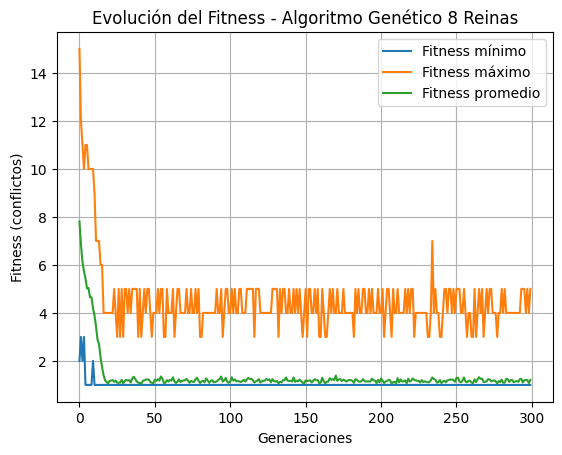

In [23]:
graficar_fitness(fmin, fmax, fmean)

In [37]:
import numpy as np

num_experimentos = 100

generaciones_resultado = []
exitos = 0

for _ in range(num_experimentos):

    solucion, fmin, fmax, fmean, generacion = algoritmo_genetico()

    generaciones_resultado.append(generacion)

    if solucion is not None:
        exitos += 1

No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución 

In [38]:
porcentaje_exito = (exitos / num_experimentos) * 100

print("Porcentaje de éxito:", porcentaje_exito, "%")

Porcentaje de éxito: 71.0 %


In [39]:
generaciones_exito = [g for g in generaciones_resultado if g < 300]

promedio = np.mean(generaciones_exito)
desviacion = np.std(generaciones_exito)

print("Promedio de generaciones:", promedio)
print("Desviación estándar:", desviacion)

Promedio de generaciones: 109.18
Desviación estándar: 131.968888757919


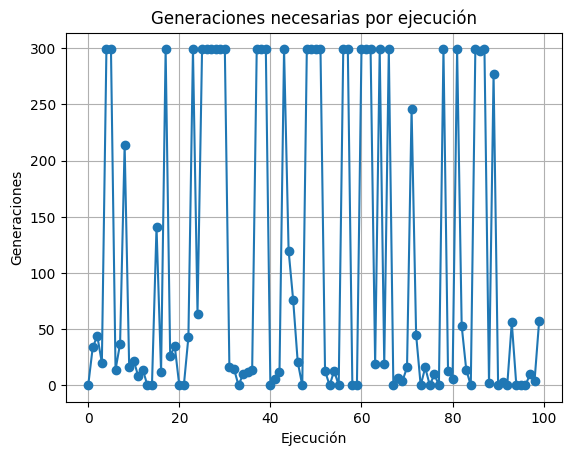

In [40]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(generaciones_resultado, marker='o')

plt.xlabel("Ejecución")
plt.ylabel("Generaciones")
plt.title("Generaciones necesarias por ejecución")

plt.grid()

plt.show()

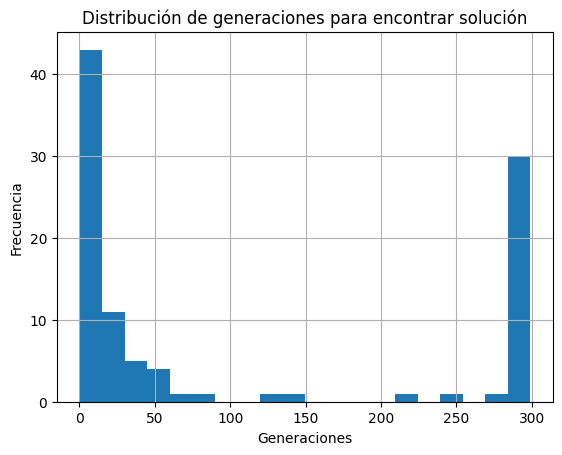

In [41]:
plt.figure()

plt.hist(generaciones_resultado, bins=20)

plt.xlabel("Generaciones")
plt.ylabel("Frecuencia")
plt.title("Distribución de generaciones para encontrar solución")

plt.grid()

plt.show()

In [49]:
def algoritmo_genetico_intercambio() -> npt.NDArray[np.int8] | None:
    """Resuelve el problema de las 8 reinas usando un algoritmo genético."""

    # Parámetros
    # TODO: Definir los parámetros
    tamano_poblacion: int = 100
    max_generaciones: int = 300
    tasa_mutacion: float = 0.10
    fitness_min: list[int] = []
    fitness_max: list[int] = []
    fitness_mean: list[int] = []

    # TODO: Generar población inicial
    poblacion: npt.NDArray[np.int8] = generar_poblacion()

    for generacion in range(max_generaciones):

        # TODO: Calcular aptitudes de toda la población para verificar si ya hay una solución
        aptitudes: npt.NDArray[np.int8] = calcular_aptitud(poblacion)

        fitness_min.append(np.min(aptitudes))
        fitness_max.append(np.max(aptitudes))
        fitness_mean.append(np.mean(aptitudes))

        # TODO: Verificar si hay solución
        if 0 in aptitudes:
            posicion = aptitudes.index(0)
            poblacion[posicion] = list(poblacion[posicion])
            return poblacion[posicion], fitness_min, fitness_max, fitness_mean, generacion
        # Si hay solución termina el algoritmo, y retornar la solución
        # De lo contrario continua con el proceso de evolución

        # Nueva generación
        nueva_poblacion: list[npt.NDArray[np.int8]] = []

        padre1: npt.NDArray[np.int8]
        padre2: npt.NDArray[np.int8]
        hijo1: npt.NDArray[np.int8]
        hijo2: npt.NDArray[np.int8]
        
        poblacion_con_aptitud = list(zip(poblacion, aptitudes))

        for _ in range(tamano_poblacion // 2):
            padre1, padre2 = seleccionar_padres(poblacion_con_aptitud)

            hijo1, hijo2 = cruzar(padre1, padre2)

            hijo1 = mutar_intercambio(hijo1, tasa_mutacion)
            hijo2 = mutar_intercambio(hijo2, tasa_mutacion)

            # Construye a la nueva población con los hijos
            nueva_poblacion.append(hijo1)
            nueva_poblacion.append(hijo2)

        # Sustituye a la población completa de padres por los hijos
        poblacion = np.array(nueva_poblacion, dtype=np.int8)

    print("No se encontró solución en el número máximo de generaciones.")
    return None, fitness_min, fitness_max, fitness_mean, generacion

In [50]:
import numpy as np

num_experimentos = 100

generaciones_resultado = []
exitos = 0

for _ in range(num_experimentos):

    solucion, fmin, fmax, fmean, generacion = algoritmo_genetico_intercambio()

    generaciones_resultado.append(generacion)

    if solucion is not None:
        exitos += 1

No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
No se encontró solución 

In [51]:
porcentaje_exito = (exitos / num_experimentos) * 100

print("Porcentaje de éxito:", porcentaje_exito, "%")

Porcentaje de éxito: 68.0 %


In [52]:
generaciones_exito = [g for g in generaciones_resultado if g < 300]

promedio = np.mean(generaciones_exito)
desviacion = np.std(generaciones_exito)

print("Promedio de generaciones:", promedio)
print("Desviación estándar:", desviacion)

Promedio de generaciones: 105.07
Desviación estándar: 135.42675178855913


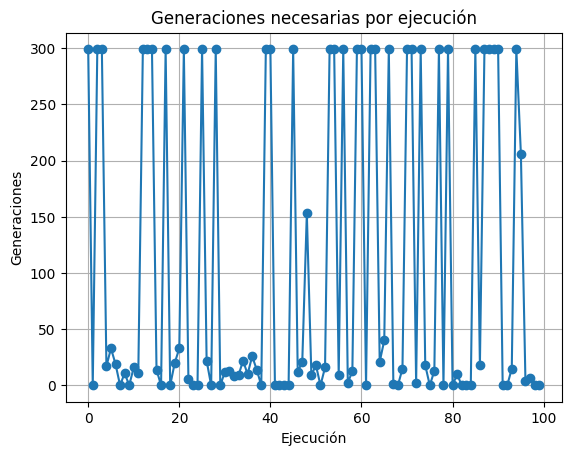

In [53]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(generaciones_resultado, marker='o')

plt.xlabel("Ejecución")
plt.ylabel("Generaciones")
plt.title("Generaciones necesarias por ejecución")

plt.grid()

plt.show()

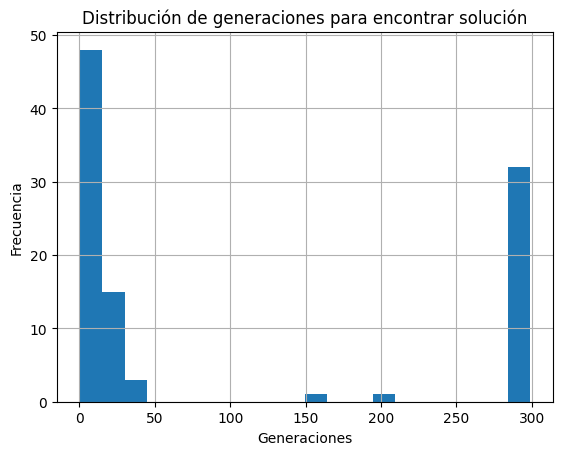

In [54]:
plt.figure()

plt.hist(generaciones_resultado, bins=20)

plt.xlabel("Generaciones")
plt.ylabel("Frecuencia")
plt.title("Distribución de generaciones para encontrar solución")

plt.grid()

plt.show()